Fase 1: IMPORTAZIONE DEI FILE, DELLE LIBRERIE E PRIMA VERIFICA VISIVA DEL DATASET
il primo passaggio effettuato è stato l'importazione delle librerie pandas (per convertire il file csv in un dataframe), numpy per le operazioni matematiche sui dati, seaborn e matlplotlib per i grafici.
Successivamente è stato importato e convertito il contenuto del dataset in un Dataframe. E' stato effettuata una prima analisi visiva del dataset, ed è stata notata l'assenza di attributi con valori nulli in ogni soggetto del campionamento.


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
#caricamento del file contenente il dataset in formato csv e creazione del df di pandas
df = pd.read_csv("diabetes_binary_5050split_health_indicators_BRFSS2015.csv")
# ispezionamento visivo delle prime cinque righe del dataset 
print("-"*40+ "prime 5 righe del dataset"+ "-"*40)
display(df.head(5))
#controllo  tipi dei dati e valori mancanti
print("-"*40+ "info del dataset" + "-"*40)
df.info()

----------------------------------------prime 5 righe del dataset----------------------------------------


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,3.0,5.0,30.0,0.0,1.0,4.0,6.0,8.0
1,0.0,1.0,1.0,1.0,26.0,1.0,1.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,12.0,6.0,8.0
2,0.0,0.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,10.0,0.0,1.0,13.0,6.0,8.0
3,0.0,1.0,1.0,1.0,28.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,3.0,0.0,3.0,0.0,1.0,11.0,6.0,8.0
4,0.0,0.0,0.0,1.0,29.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,8.0,5.0,8.0


----------------------------------------info del dataset----------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70692 entries, 0 to 70691
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Diabetes_binary       70692 non-null  float64
 1   HighBP                70692 non-null  float64
 2   HighChol              70692 non-null  float64
 3   CholCheck             70692 non-null  float64
 4   BMI                   70692 non-null  float64
 5   Smoker                70692 non-null  float64
 6   Stroke                70692 non-null  float64
 7   HeartDiseaseorAttack  70692 non-null  float64
 8   PhysActivity          70692 non-null  float64
 9   Fruits                70692 non-null  float64
 10  Veggies               70692 non-null  float64
 11  HvyAlcoholConsump     70692 non-null  float64
 12  AnyHealthcare         70692 non-null  float64
 13  NoDocbcCost           70

Fase 2: ANALISI DELLE CORRELAZIONI
E' stata generata l' HeatMap, è stata effettuata la divisione tra le colonne degli Attributi e la colonna dell' Etichetta
E' stata calcolata la matrice di correlazione tra tutte le variabili del dataset, ed è stata creata una heatmap che mostra quali sono i legami più forti.


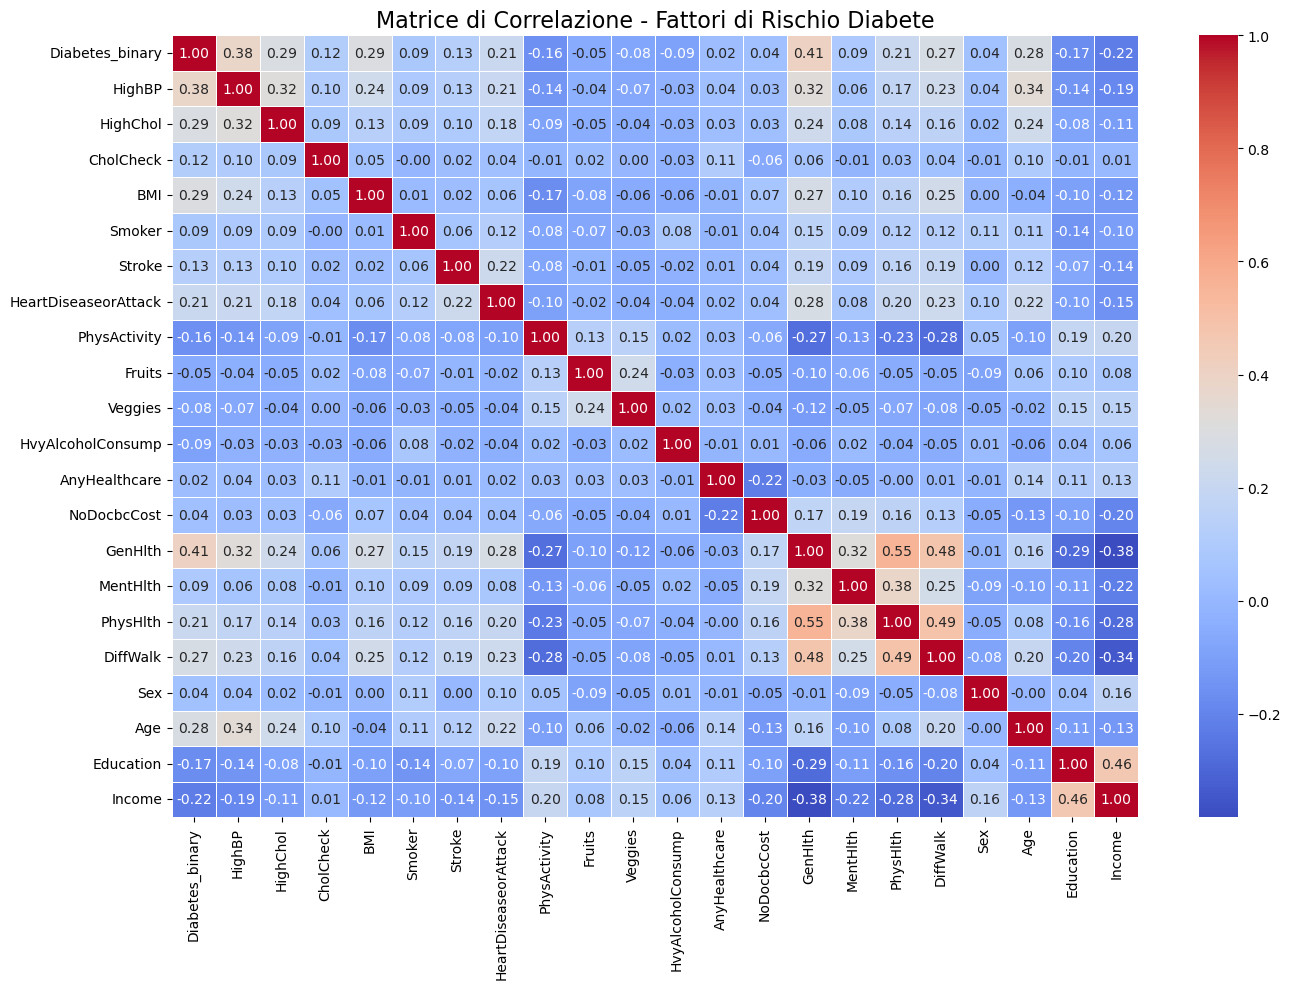

I fattori che più influenzano la presenza di Diabete sono (in valore assoluto):

GenHlth                 0.407612
HighBP                  0.381516
BMI                     0.293373
HighChol                0.289213
Age                     0.278738
DiffWalk                0.272646
Income                  0.224449
PhysHlth                0.213081
HeartDiseaseorAttack    0.211523
Education               0.170481
PhysActivity            0.158666
Stroke                  0.125427
CholCheck               0.115382
HvyAlcoholConsump       0.094853
MentHlth                0.087029
Smoker                  0.085999
Veggies                 0.079293
Fruits                  0.054077
Sex                     0.044413
NoDocbcCost             0.040977
AnyHealthcare           0.023191
dtype: float64


In [ ]:

# Calcolo della matrice di correlazione di Pearson tra tutte le variabili del dataset
corr_matrix = df.corr()

# Creazione del grafico della matrice di correlazione tramite una heatmap (mappa di calore)
plt.figure(figsize=(14, 10))
# Generazione heatmap impostando i valori numerici all'interno (annot=True) e la scala di colori da freddo a caldo (coolwarm)
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Matrice di Correlazione - Fattori di Rischio Diabete", fontsize=16)
plt.tight_layout()
plt.show()  # Mostra il grafico a schermo per individuare visivamente i legami più forti

# Separazione delle features (X) dalla variabile target (y)
X = df.drop(["Diabetes_binary"], axis=1)
y = df["Diabetes_binary"]  # Il target rappresenta lo stato del paziente (0 = Sano, 1 = Diabetico)

# Calcolo della correlazione specifica di tutte le features con la variabile target y
# Uso del valore assoluto (.abs()) per concentrare il calcolo unicamente sulla FORZA del legame, 
# eliminanando i segni meno dei legami inversi, e ordino i risultati dal più grande al più piccolo.
correlation_with_target = X.corrwith(y).abs().sort_values(ascending=False)

print("=======================================================================================")
print("I fattori che più influenzano la presenza di Diabete sono (in valore assoluto):\n")
print(correlation_with_target)
print("=======================================================================================")

è possibile  quindi notare delle correlazioni abbastanza forti tra GenHlth( percezione della propria salute), HighBP( pressione sanguigna alta), BMI ( obesità ) e il diabete.

Fase 3: DIVISIONE DEL DATASET

si è passati poi alla divisione del DataSet in Train Set e Test Set,
tramite l'uso di uno split 80/20 e di stratify che assicura, sia nel test set che nel train set, che ci siano in percentuali uguali pazienti malati e non, in modo da evitare sbilanciamenti.
E'stata verificata che la divisione del DataSet fosse corretta.
E' stato mostrato il numero di pazienti totali del campionamento, il numero di campioni usati nella fase di train(80%) e il numero di campioni usati per il test(20%). 
Viene mostrato inoltre il numero di campioni diabetici e non diabetici nella fase di train, assicurando di aver fornito un dataset bilanciato. 

In [8]:
# Importiamo la funzione train_test_split da scikit-learn
from sklearn.model_selection import train_test_split

# Dividiamo le caratteristiche (X) e il target (y) in Train (80%) e Test (20%)
# - test_size=0.20 indica che il 20% dei dati sarà "nascosto" per l'esame finale
# - random_state=42 serve a rendere il risultato riproducibile, in modo da bloccare il generatore di numeri casuali sempre allo stesso numero.
# - stratify=y  garantisce che nel train e nel test ci sia sempre il 50% di sani e il 50% di malati
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

print("=======================================================================================")
print("Suddivisione dei dati completata!")
print(f"Totale campioni: {X.shape[0]}") #conta le righe di X
print(f"Campioni per l'Addestramento (X_train): {X_train.shape[0]}") #conta le righe di X_train
print(f"Campioni per il Test finale (X_test): {X_test.shape[0]}") #conta le righe di X_test
print("=======================================================================================")

# Verifichiamo che la stratificazione abbia funzionato 
print("\nBilanciamento classi nel Training Set (y_train):")
print(y_train.value_counts(normalize=True)) #conta i pazienti diabetici e non diabetici e poi normalizza, in modo da avere delle percentuali
print("=======================================================================================")

Suddivisione dei dati completata!
Totale campioni: 70692
Campioni per l'Addestramento (X_train): 56553
Campioni per il Test finale (X_test): 14139

Bilanciamento classi nel Training Set (y_train):
Diabetes_binary
1.0    0.500009
0.0    0.499991
Name: proportion, dtype: float64


FASE 4: ADDESTRAMENTO DEL MODELLO E VALUTAZIONE DELLE METRICHE
come primo algoritmo è scelto il decision tree:
il decision tree è un algoritmo che ha la struttura di un albero, le radici sono le domande più generali, man mano che crescono i rami, le domande iniziano ad essere sempre più specifiche, fino ad arrivare alle foglie che sono gli output. Per evitare fenomeni di overfitting è stata scelta una profondità massima di 5

L'Albero di Decisione è stato addestrato con successo!

MATRICE DI CONFUSIONE (Confusion Matrix):
[[4853 2217]
 [1592 5477]]

REPORT DELLE METRICHE DI CLASSIFICAZIONE:
              precision    recall  f1-score   support

         0.0       0.75      0.69      0.72      7070
         1.0       0.71      0.77      0.74      7069

    accuracy                           0.73     14139
   macro avg       0.73      0.73      0.73     14139
weighted avg       0.73      0.73      0.73     14139



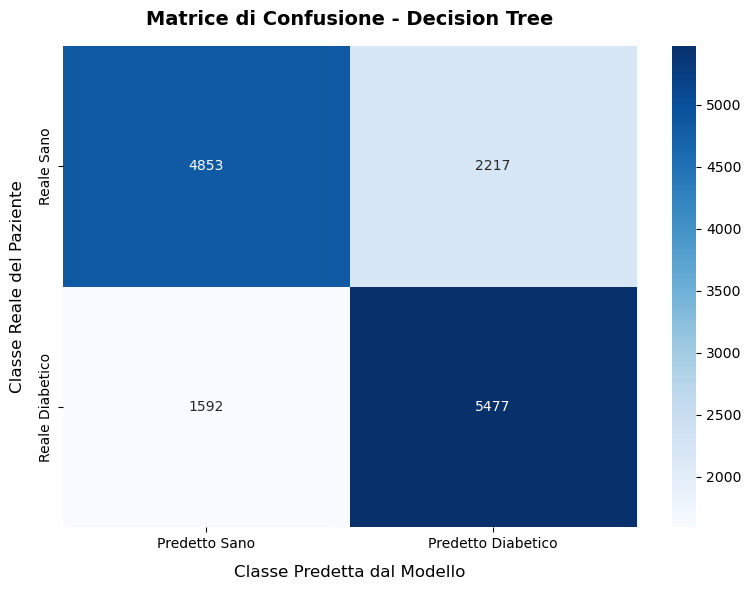

In [9]:

# 1. IMPORTAZIONE DEL MODELLO E DELLE METRICHE
# Importiamo l'algoritmo DecisionTreeClassifier 
from sklearn.tree import DecisionTreeClassifier
# Importiamo il report delle metriche e la matrice di confusione per valutare i risultati
from sklearn.metrics import classification_report, confusion_matrix

# 2. CREAZIONE E ADDESTRAMENTO DEL MODELLO
# Creiamo l'oggetto del modello. Impostiamo un max_depth (profondità massima) per evitare 
# che l'albero cresca all'infinito memorizzando troppi dettagli inutili (overfitting).
# Usiamo random_state=42 per garantire che l'albero si sviluppi sempre nello stesso modo.
albero = DecisionTreeClassifier(max_depth=5, random_state=42)

# Avviamo l'addestramento vero e proprio tramite il metodo .fit()
# In questo momento il modello sta studiando le domande (X_train) e le risposte (y_train)
albero.fit(X_train, y_train)
print("L'Albero di Decisione è stato addestrato con successo!\n")

# 3. PREVISIONE SUI DATI DI TEST (L'ESAME AL BUIO)
# Ora chiediamo all'albero di indovinare la diagnosi per i pazienti del Test Set (X_test)
y_pred = albero.predict(X_test)

# 4. VALUTAZIONE DELLE PRESTAZIONI
print("=======================================================================================")
print("MATRICE DI CONFUSIONE (Confusion Matrix):")
# La matrice mostra i Veri Positivi, Veri Negativi, Falsi Positivi e Falsi Negativi
print(confusion_matrix(y_test, y_pred))
print("=======================================================================================\n")

print("REPORT DELLE METRICHE DI CLASSIFICAZIONE:")
# classification_report calcola Accuracy, Precision, Recall e F1-Score per sani e malati
print(classification_report(y_test, y_pred))
print("=======================================================================================")
# =======================================================================================
# VISUALIZZAZIONE GRAFICA DELLA MATRICE DI CONFUSIONE (CONFUSION MATRIX HEATMAP)
# =======================================================================================
# 2. Configuriamo la figura con Matplotlib
plt.figure(figsize=(8, 6))

# 3. Disegnamo la mappa di calore con Seaborn
# - annot=True: inserisce i numeri reali dentro i quadrati
# - fmt="d": dice a Python di stampare i numeri come interi (evita la notazione scientifica)
# - cmap="Blues": colora il grafico con sfumature di blu (più è scuro, più sono i pazienti in quella cella)
# - xticklabels e yticklabels: sostituiscono gli 0 e 1 generici con etichette mediche chiare
sns.heatmap(confusion_matrix(y_test,y_pred), annot=True, fmt="d", cmap="Blues",
xticklabels=["Predetto Sano", "Predetto Diabetico"],
yticklabels=["Reale Sano", "Reale Diabetico"])

# 4. Aggiungiamo i titoli e le etichette degli assi
plt.title("Matrice di Confusione - Decision Tree", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Classe Predetta dal Modello", fontsize=12, labelpad=10)
plt.ylabel("Classe Reale del Paziente", fontsize=12, labelpad=10)

# Ottimizziamo il layout e mostriamo il grafico
plt.tight_layout()
plt.show()

I risultati del Decision Tree confermano l'efficacia del modello.
E' stata ottenuta un'accuracy globale del 73%.
La cosa più rilevante dal punto di vista medico è il valore di Recall sulla classe dei diabetici (1.0), pari al 77%: questo significa che l'algoritmo è in grado di intercettare quasi l'80% dei soggetti malati. 
La Precision del 71% ci indica che i falsi allarmi sono contenuti.
Inoltre, il fatto che l'F1-Score sia bilanciato tra la classe 0 e la classe 1 (rispettivamente 0.72 e 0.74) è la prova matematica che la stratificazione iniziale ha funzionato, impedendo al modello di polarizzarsi su una sola risposta."

FASE 5: ADDESTRAMENTO E VALUTAZIONE DELLA RANDOM FOREST

La Random Forest è stata addestrata con successo!

MATRICE DI CONFUSIONE - RANDOM FOREST:
[[4930 2140]
 [1478 5591]]

REPORT DELLE METRICHE DI CLASSIFICAZIONE - RANDOM FOREST:
              precision    recall  f1-score   support

         0.0       0.77      0.70      0.73      7070
         1.0       0.72      0.79      0.76      7069

    accuracy                           0.74     14139
   macro avg       0.75      0.74      0.74     14139
weighted avg       0.75      0.74      0.74     14139



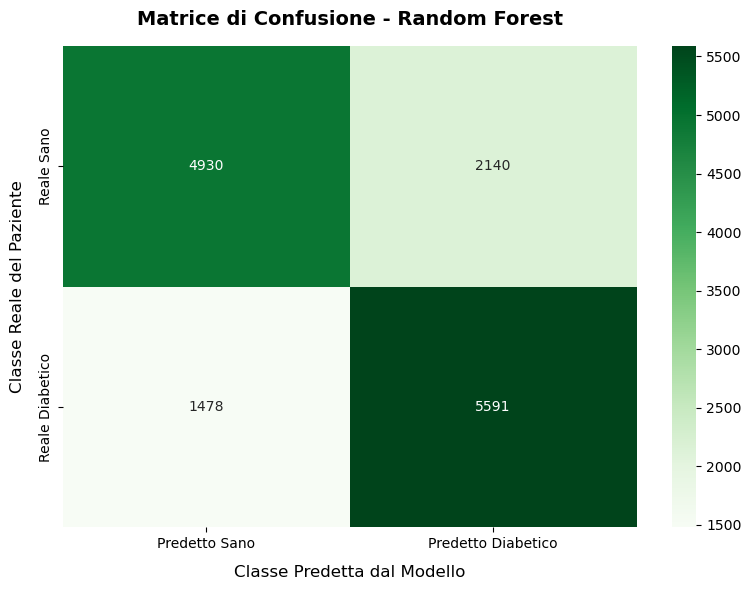

In [10]:

# 1. IMPORTAZIONE DEL MODELLO
# Importiamo RandomForestClassifier dal modulo 'ensemble'.
from sklearn.ensemble import RandomForestClassifier

# 2. INIZIALIZZAZIONE E ADDESTRAMENTO
# - n_estimators=100: creiamo una foresta composta da 100 alberi decisionali indipendenti
# - max_depth=6: limitiamo leggermente la profondità per evitare overfitting
# - random_state=42: blocchiamo il generatore di casualità per la riproducibilità
foresta = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42)

# Avviamo lo studio sui dati del Training Set tramite il metodo .fit()
foresta.fit(X_train, y_train)
print("La Random Forest è stata addestrata con successo!\n")

# 3. PREVISIONE SUI DATI DI TEST (L'ESAME)
y_pred_rf = foresta.predict(X_test)

# 4. VALUTAZIONE DELLE PRESTAZIONI DEL NUOVO MODELLO
print("=======================================================================================")
print("MATRICE DI CONFUSIONE - RANDOM FOREST:")
print(confusion_matrix(y_test, y_pred_rf))
print("=======================================================================================\n")

print("REPORT DELLE METRICHE DI CLASSIFICAZIONE - RANDOM FOREST:")
print(classification_report(y_test, y_pred_rf))
print("=======================================================================================")
# Generiamo la heatmap per la Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(8, 6))

sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens", # Usiamo il verde per distinguerlo dall'albero di prima
            xticklabels=["Predetto Sano", "Predetto Diabetico"],
            yticklabels=["Reale Sano", "Reale Diabetico"])

plt.title("Matrice di Confusione - Random Forest", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Classe Predetta dal Modello", fontsize=12, labelpad=10)
plt.ylabel("Classe Reale del Paziente", fontsize=12, labelpad=10)
plt.tight_layout()
plt.show()

Si nota come ci siano delle migliorie rispetto ai parametri del singolo albero, ma che non alzino di molto le percentuali. Questo probabilmente avviene perchè siamo vicino al massimo livello che questo DataSet può fornirci.


In questo studio siamo partiti dall'esplorazione di un dataset clinico reale sul Diabete, verificandone la pulizia (assenza di valori nulli) e il perfetto bilanciamento delle classi. Attraverso l'analisi delle correlazioni (Fase 2), abbiamo isolato caratteristiche ad alto valore predittivo, come la salute generale percepita (GenHlth), la pressione sanguigna (HighBP) e l'indice di massa corporea (BMI).

Successivamente, abbiamo implementato e confrontato due algoritmi di classificazione supervisionata:
1. Decision Tree: Un modello snello e altamente interpretabile (profondità massima fissata a 5 per evitare l'overfitting), capace di raggiungere un'ottima Recall del 77% e un'accuratezza globale del 73%.
2. Random Forest: Un modello di Ensemble (100 alberi decisionali in parallelo) che, sfruttando il principio della votazione a maggioranza, ha superato il singolo albero portando l'accuratezza al 74% e la Recall al 79%.

Dal punto di vista informatico, il leggero incremento prestazionale conferma che i modelli hanno saturato il segnale predittivo disponibile nei dati di screening comportamentale. Dal punto di vista clinico, l'adozione della Random Forest risulta pienamente giustificata in quanto riduce significativamente la quota di Falsi Negativi, permettendo di intercettare precocemente un numero maggiore di pazienti affetti da diabete.